# KVSwitch — Background & Motivation

Profiling data from `results/profiling/inference_traces.csv` — 150 measurements (6 prompt lengths × 5 prefix ratios × 5 trials) collected via UDP client → vLLM server on a single GPU.

In [1]:
import os
import statistics
from collections import defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from kvswitch.vllm.profiling import ProfilingResult, load_results_csv

# Ensure data paths resolve relative to repo root, not the notebook location.
os.chdir(
    Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
)

RESULTS_CSV = Path("results/profiling/inference_traces.csv")
FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results = load_results_csv(RESULTS_CSV)
print(f"Loaded {len(results)} measurements")

Loaded 150 measurements


In [ ]:
def group_results(
    results: list[ProfilingResult],
    key_fn,
) -> dict[tuple, list[ProfilingResult]]:
    """Group results by an arbitrary key function."""
    groups: dict[tuple, list[ProfilingResult]] = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def stats(values: list[float]) -> tuple[float, float]:
    """Return (mean, stdev). stdev=0 for single values."""
    m = statistics.mean(values)
    s = statistics.stdev(values) if len(values) > 1 else 0.0
    return m, s


# Seaborn styling for publication-friendly figures.
sns.set_theme(style="whitegrid")
sns.set_palette(["tab:blue", "tab:green", "tab:orange", "tab:red", "tab:purple", "tab:brown"])
matplotlib.rcParams["font.size"] = 10
matplotlib.rcParams["axes.labelsize"] = 11
matplotlib.rcParams["axes.titlesize"] = 12
matplotlib.rcParams["legend.fontsize"] = 9
matplotlib.rcParams["xtick.labelsize"] = 9
matplotlib.rcParams["ytick.labelsize"] = 9
matplotlib.rcParams["figure.dpi"] = 300
matplotlib.rcParams["savefig.dpi"] = 300
matplotlib.rcParams["savefig.bbox"] = "tight"

## TTFT vs Prompt Length

Shows how prefix caching reduces TTFT, especially for longer prompts.

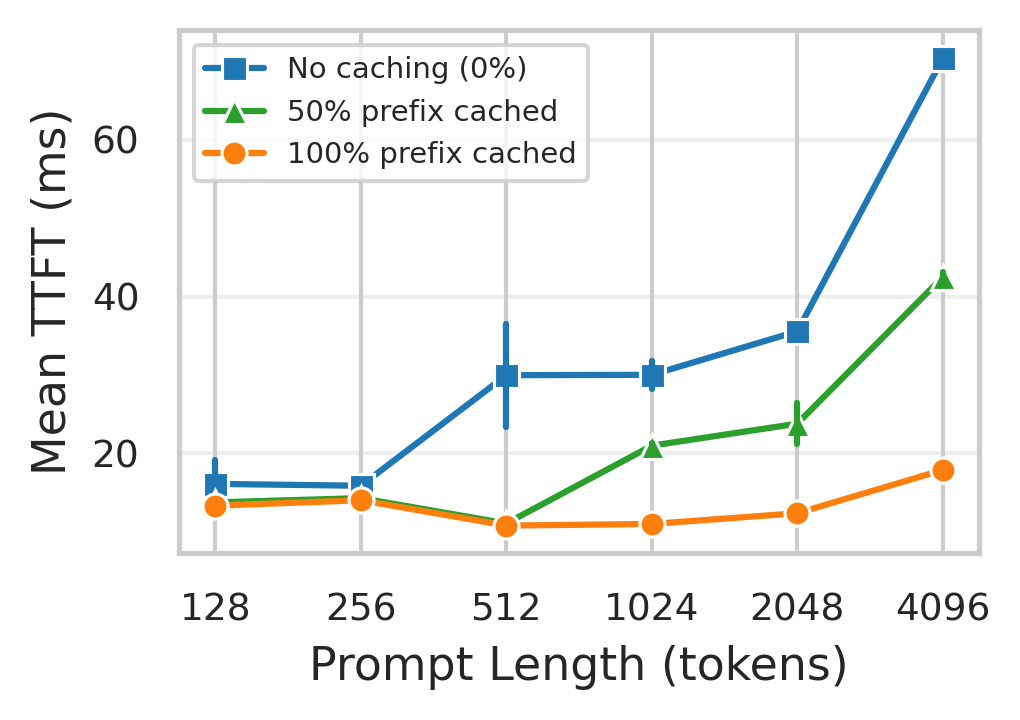

Saved to results/figures/ttft_vs_prompt_length.png


In [3]:
prompt_lengths = sorted({r.prompt_tokens for r in results})
selected_ratios = [0.0, 0.5, 1.0]
labels = {0.0: "No caching (0%)", 0.5: "50% prefix cached", 1.0: "100% prefix cached"}
colors = {0.0: "tab:blue", 0.5: "tab:green", 1.0: "tab:orange"}
markers = {
    labels[0.0]: "s",
    labels[0.5]: "^",
    labels[1.0]: "o",
}

grouped = group_results(results, lambda r: (r.prompt_tokens, r.prefix_ratio))

ttft_prompt_lengths = []
ttft_values = []
ttft_labels = []
for ratio in selected_ratios:
    for pl in prompt_lengths:
        vals = [r.ttft * 1000 for r in grouped[(pl, ratio)]]  # ms
        ttft_prompt_lengths.extend([pl] * len(vals))
        ttft_values.extend(vals)
        ttft_labels.extend([labels[ratio]] * len(vals))

fig, ax = plt.subplots(figsize=(3.5, 2.5))
sns.lineplot(
    x=ttft_prompt_lengths,
    y=ttft_values,
    hue=ttft_labels,
    style=ttft_labels,
    hue_order=[labels[ratio] for ratio in selected_ratios],
    style_order=[labels[ratio] for ratio in selected_ratios],
    palette={labels[ratio]: colors[ratio] for ratio in selected_ratios},
    markers=markers,
    dashes=False,
    estimator="mean",
    errorbar="sd",
    err_style="bars",
    linewidth=1.5,
    ax=ax,
)

ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(prompt_lengths)
ax.set_xlabel("Prompt Length (tokens)")
ax.set_ylabel("Mean TTFT (ms)")
ax.legend(fontsize=7)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

fig.savefig(FIGURES_DIR / "ttft_vs_prompt_length.png")
fig.savefig(FIGURES_DIR / "ttft_vs_prompt_length.pdf")
plt.show()
print(f"Saved to {FIGURES_DIR / 'ttft_vs_prompt_length.png'}")

## L7 Prefix-Aware Routing Overhead

Shows the routing overhead of a dedicated L7 prefix-aware router as a function of prompt length. The L7 router tokenizes the prompt, hashes token blocks, and performs radix tree lookup — all in the critical path.

- **No Router**: Cached TTFT only (lower bound)
- **L7 Router**: Cached TTFT + measured prefix-aware routing delay (tokenization + hashing + lookup)

Prompts are constructed by decoding synthetic token IDs (matching the evaluation workload's system prompt construction) to ensure realistic tokenization cost.

In [4]:
import random

from kvswitch.router.l7_router import L7Router

MODEL = "meta-llama/Llama-3.2-3B-Instruct"
router = L7Router(model=MODEL, n_workers=2, block_size=16)


# Generate prompts by decoding synthetic token IDs.
def make_prompt_text(n_tokens: int, seed: int = 42) -> tuple[str, list[int]]:
    """Generate a prompt string whose tokenization is ~n_tokens long."""
    rng = random.Random(seed)
    token_ids = [rng.randint(100, 10000) for _ in range(n_tokens)]
    return router.tokenizer.decode(token_ids), token_ids


# Measure L7 routing overhead (tokenize + hash + lookup) per prompt length.
l7_overheads: dict[int, list[float]] = defaultdict(list)
n_warmup = 3
n_measure = 20

for pl in prompt_lengths:
    sample_text, token_ids = make_prompt_text(pl)
    for _ in range(n_warmup):
        router.route(sample_text, token_ids)
    for _ in range(n_measure):
        result = router.route(sample_text, token_ids)
        l7_overheads[pl].append(result.total_ms)

# Compute mean TTFT per prompt length under the cache-hit condition.
ttft_cached = {}
for pl in prompt_lengths:
    ttft_cached[pl] = stats([r.ttft * 1000 for r in grouped[(pl, 1.0)]])[0]

for pl in prompt_lengths:
    m, s = stats(l7_overheads[pl])
    improvement = (m / ttft_cached[pl] * 100) if m > 0 else float("inf")
    print(f"  {pl:>5} tokens: L7 overhead = {m:.3f} ± {s:.3f} ms ({improvement:.2f}%)")

/home/noppanat/Workspace/Courses/CS6204/kvswitch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/noppanat/Workspace/Courses/CS6204/kvswitch/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


    128 tokens: L7 overhead = 0.148 ± 0.009 ms (1.11%)
    256 tokens: L7 overhead = 0.282 ± 0.007 ms (2.02%)
    512 tokens: L7 overhead = 0.584 ± 0.020 ms (5.43%)
   1024 tokens: L7 overhead = 1.176 ± 0.015 ms (10.73%)
   2048 tokens: L7 overhead = 2.403 ± 0.020 ms (19.48%)
   4096 tokens: L7 overhead = 4.920 ± 0.048 ms (27.54%)


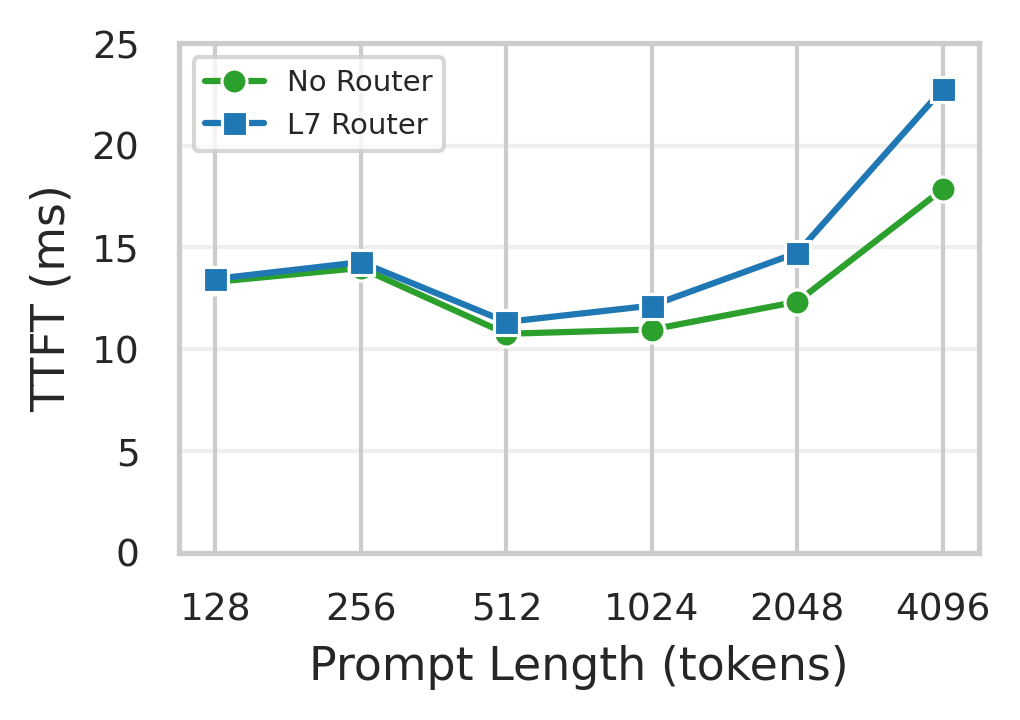

Saved to results/figures/l7_router_overhead.png


In [5]:
# Compose end-to-end TTFT: No Router (cached TTFT only) vs L7 Router (+ routing overhead).
line_prompt_lengths = []
line_schemes = []
line_ttfts = []
for pl in prompt_lengths:
    no_router = ttft_cached[pl]
    l7 = stats(l7_overheads[pl])[0] + ttft_cached[pl]
    line_prompt_lengths.extend([pl, pl])
    line_schemes.extend(["No Router", "L7 Router"])
    line_ttfts.extend([no_router, l7])

fig, ax = plt.subplots(figsize=(3.5, 2.5))
sns.lineplot(
    x=line_prompt_lengths,
    y=line_ttfts,
    hue=line_schemes,
    style=line_schemes,
    hue_order=["No Router", "L7 Router"],
    style_order=["No Router", "L7 Router"],
    palette={"No Router": "tab:green", "L7 Router": "tab:blue"},
    markers={"No Router": "o", "L7 Router": "s"},
    dashes=False,
    linewidth=1.5,
    ax=ax,
)

ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_ylim(0, max(line_ttfts) * 1.1)
ax.set_xticks(prompt_lengths)
ax.set_xlabel("Prompt Length (tokens)")
ax.set_ylabel("TTFT (ms)")
ax.legend(fontsize=7)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

fig.savefig(FIGURES_DIR / "l7_router_overhead.png")
fig.savefig(FIGURES_DIR / "l7_router_overhead.pdf")
plt.show()
print(f"Saved to {FIGURES_DIR / 'l7_router_overhead.png'}")

## Cache Hit Rate & TTFT vs Prefix Sharing Ratio

Shows the sensitivity of TTFT and effective cache hit rate to the fraction of the prompt that is a shared prefix. Averaged across all prompt lengths.

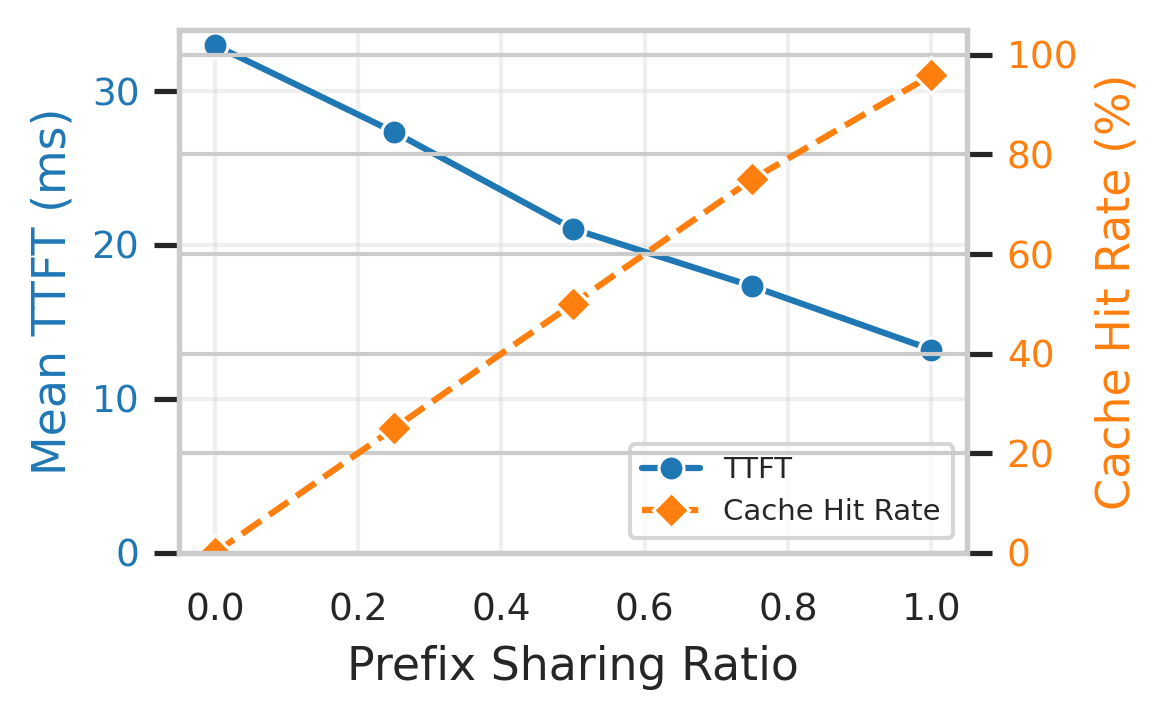

Saved to results/figures/cache_sensitivity.png


In [6]:
prefix_ratios = sorted({r.prefix_ratio for r in results})

ratio_ttfts = []
ratio_ttft_values = []
ratio_hitrates = []
ratio_hitrate_values = []

for ratio in prefix_ratios:
    ttfts = [r.ttft * 1000 for r in results if r.prefix_ratio == ratio]
    hitrates = [
        100 * r.num_cached_tokens / r.prompt_tokens
        for r in results
        if r.prefix_ratio == ratio
    ]
    ratio_ttfts.extend([ratio] * len(ttfts))
    ratio_ttft_values.extend(ttfts)
    ratio_hitrates.extend([ratio] * len(hitrates))
    ratio_hitrate_values.extend(hitrates)

fig, ax1 = plt.subplots(figsize=(4, 2.5))

color_ttft = "tab:blue"
color_hit = "tab:orange"

sns.lineplot(
    x=ratio_ttfts,
    y=ratio_ttft_values,
    ax=ax1,
    color=color_ttft,
    marker="o",
    linewidth=1.5,
    estimator="mean",
    errorbar=None,
    err_style="bars",
    label="TTFT",
)
ax1.set_xlabel("Prefix Sharing Ratio")
ax1.set_ylabel("Mean TTFT (ms)", color=color_ttft)
ax1.tick_params(axis="y", labelcolor=color_ttft)
ax1.set_ylim(0, None)

ax2 = ax1.twinx()
sns.lineplot(
    x=ratio_hitrates,
    y=ratio_hitrate_values,
    ax=ax2,
    color=color_hit,
    marker="D",
    linewidth=1.5,
    linestyle="--",
    estimator="mean",
    errorbar=None,
    label="Cache Hit Rate",
)
ax2.set_ylabel("Cache Hit Rate (%)", color=color_hit)
ax2.tick_params(axis="y", labelcolor=color_hit)
ax2.set_ylim(0, 105)

# Combine legends.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=7)
ax2.legend().remove()

ax1.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(FIGURES_DIR / "cache_sensitivity.png")
fig.savefig(FIGURES_DIR / "cache_sensitivity.pdf")
plt.show()
print(f"Saved to {FIGURES_DIR / 'cache_sensitivity.png'}")

## TTFT vs Prefix Sharing Ratio by Prompt Length

Shows how TTFT changes with prefix sharing ratio for each prompt length separately.

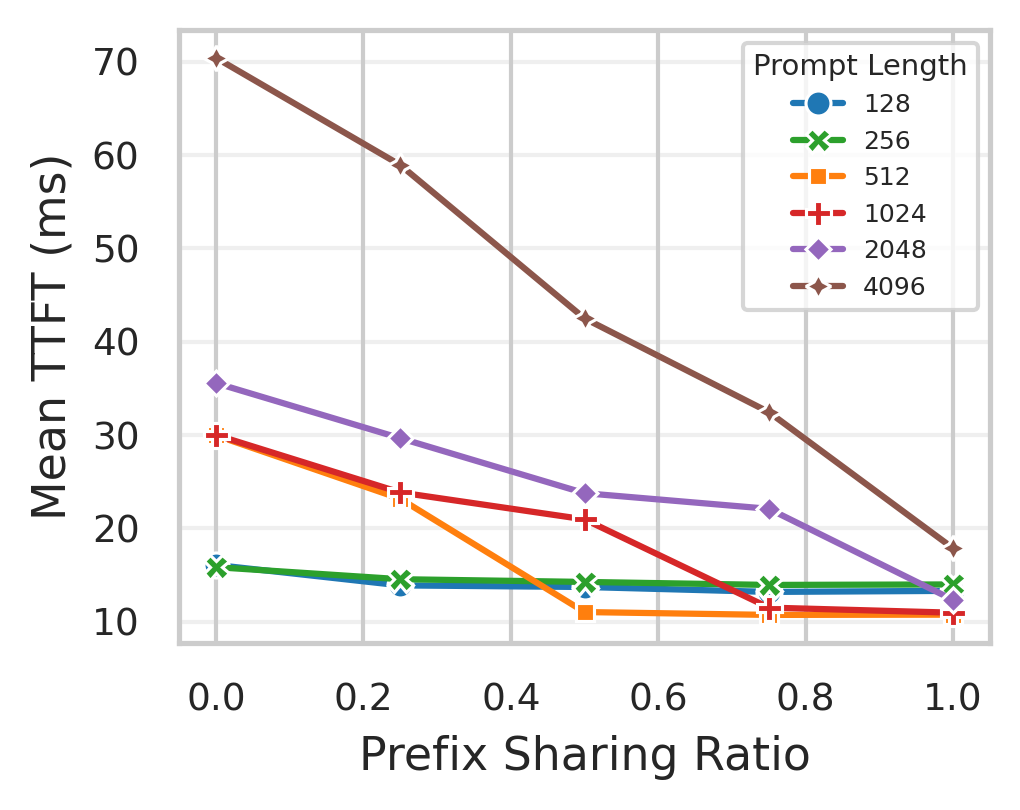

Saved to results/figures/ttft_vs_prefix_ratio_by_prompt_length.png


In [7]:
ratio_prompt_lengths = []
ratio_prompt_ratios = []
ratio_prompt_ttfts = []

for pl in prompt_lengths:
    for ratio in prefix_ratios:
        ttfts = [r.ttft * 1000 for r in grouped[(pl, ratio)]]
        ratio_prompt_lengths.extend([str(pl)] * len(ttfts))
        ratio_prompt_ratios.extend([ratio] * len(ttfts))
        ratio_prompt_ttfts.extend(ttfts)

fig, ax = plt.subplots(figsize=(3.5, 2.8))
sns.lineplot(
    x=ratio_prompt_ratios,
    y=ratio_prompt_ttfts,
    hue=ratio_prompt_lengths,
    style=ratio_prompt_lengths,
    hue_order=[str(pl) for pl in prompt_lengths],
    style_order=[str(pl) for pl in prompt_lengths],
    estimator="mean",
    errorbar=None,
    markers=True,
    dashes=False,
    linewidth=1.5,
    ax=ax,
)
ax.set_xlabel("Prefix Sharing Ratio")
ax.set_ylabel("Mean TTFT (ms)")
ax.legend(title="Prompt Length", fontsize=6, title_fontsize=7)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

fig.savefig(FIGURES_DIR / "ttft_vs_prefix_ratio_by_prompt_length.png")
fig.savefig(FIGURES_DIR / "ttft_vs_prefix_ratio_by_prompt_length.pdf")
plt.show()
print(f"Saved to {FIGURES_DIR / 'ttft_vs_prefix_ratio_by_prompt_length.png'}")